In [1]:
import joblib
import pandas as pd
import numpy as np
from plotnine import *
import patchworklib as pw

<Figure size 100x100 with 0 Axes>

In [2]:
pkl_file = "../data/test.pkl"
term_index=1

In [3]:
pre_res = joblib.load(pkl_file)
terms = pre_res.res2d.Term
term = terms[term_index]

hits = pre_res.results[term]["hits"]
resdata = pd.DataFrame({
    "res": pre_res.results[term]["RES"],
    "index": range(len(pre_res.results[term]["RES"]))
})

In [26]:
pre_res.results[term]

{'name': 'prerank',
 'es': 0.7145111663519766,
 'nes': 2.2110462028641864,
 'pval': 0.0,
 'fdr': 0.0,
 'fwerp': 0.0,
 'tag %': '19/44',
 'gene %': '9.73%',
 'lead_genes': 'Spp1;Thbs4;Col1a1;Col1a2;Thbs1;Tnc;Itga4;Hmmr;Fn1;Col6a3;Itgb3;Thbs2;Cd44;Col6a2;Itga3;Lamb1;Col6a1;Itgb5;Itgav',
 'matched_genes': 'Spp1;Thbs4;Col1a1;Col1a2;Thbs1;Tnc;Itga4;Hmmr;Fn1;Col6a3;Itgb3;Thbs2;Cd44;Col6a2;Itga3;Lamb1;Col6a1;Itgb5;Itgav;Sdc4;Col4a2;Lama2;Lamc1;Col4a1;Comp;Vwf;Col4a5;Itga9;Itgb1;Itga7;Dag1;Itga5;Itga6;Hspg2;Col4a4;Cd47;Itgb4;Itga1;Lamb2;Cd36;Lama3;Agrn;Tnxb;Reln',
 'hits': [0,
  4,
  33,
  38,
  40,
  45,
  55,
  117,
  139,
  154,
  188,
  228,
  258,
  284,
  351,
  506,
  579,
  593,
  687,
  837,
  977,
  1071,
  1174,
  1265,
  1301,
  1491,
  1613,
  2017,
  2380,
  2475,
  2516,
  2989,
  3896,
  4569,
  4919,
  5207,
  5359,
  6229,
  6300,
  6496,
  6602,
  6789,
  6932,
  6987],
 'RES': [0.14459189776189452,
  0.14444952874139338,
  0.14430715972089225,
  0.14416479070039112,
  0.264

In [27]:
nes = pre_res.results[term]["nes"]
pval = pre_res.results[term]["pval"]
fdr = pre_res.results[term]["fdr"]

In [23]:
postion_left = len(resdata)*0.80
postion_top = max(resdata["res"])*0.80

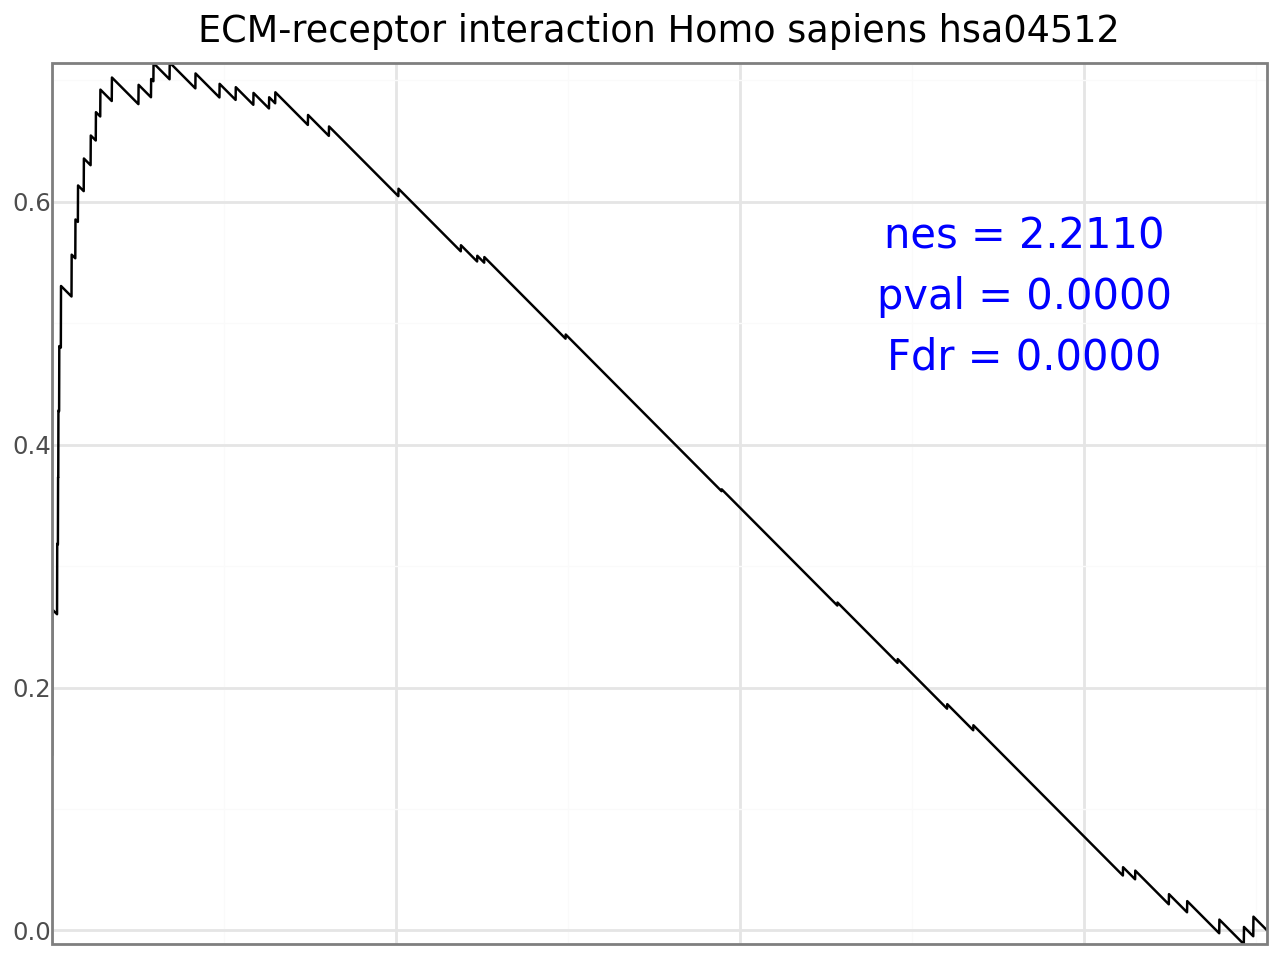

In [29]:
(ggplot(resdata, aes(x='index', y='res')) +
          geom_line() +
          theme_bw() +
          theme(axis_text_x=element_blank(),
                legend_position="none",
                axis_ticks=element_blank(),
                panel_background=element_blank()) +
         annotate(
        "text",
        x=postion_left,
        y=postion_top,
        label=f"nes = {nes:.4f}",
        color="blue",
        size=15,
        )+
         annotate(
        "text",
        x=postion_left,
        y=postion_top-0.05,
        label=f"pval = {pval:.4f}",
        color="blue",
        size=15,
        )+
         annotate(
        "text",
        x=postion_left,
        y=postion_top-0.1,
        label=f"Fdr = {fdr:.4f}",
        color="blue",
        size=15,
        )+
          xlab('') + ylab('') +
          ggtitle(term) +
          scale_x_continuous(expand=(0, 0)) +
          scale_y_continuous(expand=(0, 0)))

In [5]:
x_vals = np.linspace(0, len(resdata), len(resdata) * 10)
bg_df = pd.DataFrame({'x': x_vals})
bg_df['y'] = 0
bg_df['fill'] = bg_df['x']

p2 = (ggplot() +
        geom_vline(xintercept=hits, color='black') +
        xlim(0, len(resdata)-1) +
        scale_x_continuous(expand=(0, 0)) +
          geom_tile(data=bg_df, mapping=aes(x='x', y='y', fill='fill'),
                    width=0.1, height=10, alpha=0.4) +
          scale_fill_gradient(low="lightblue", high="purple") +
          theme(legend_position="none",
                axis_text=element_blank(),
                axis_ticks=element_blank(),
                axis_title=element_blank(),
                panel_background=element_blank()) +
          scale_y_continuous(expand=(0, 0)) +
          xlab('') + ylab('') +
          guides(color=False, fill=False, shape=False, size=False))

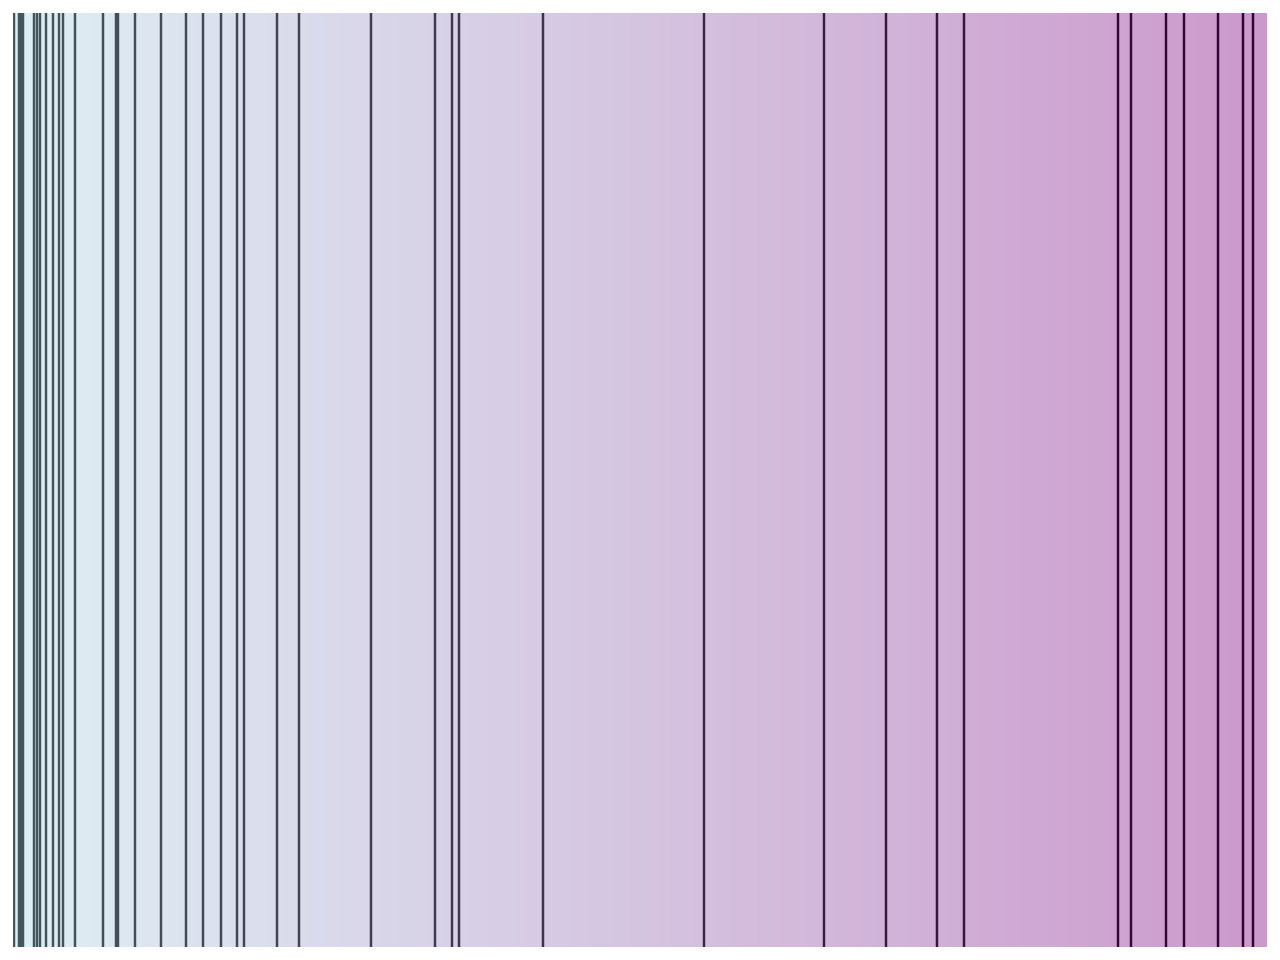

In [9]:
p2

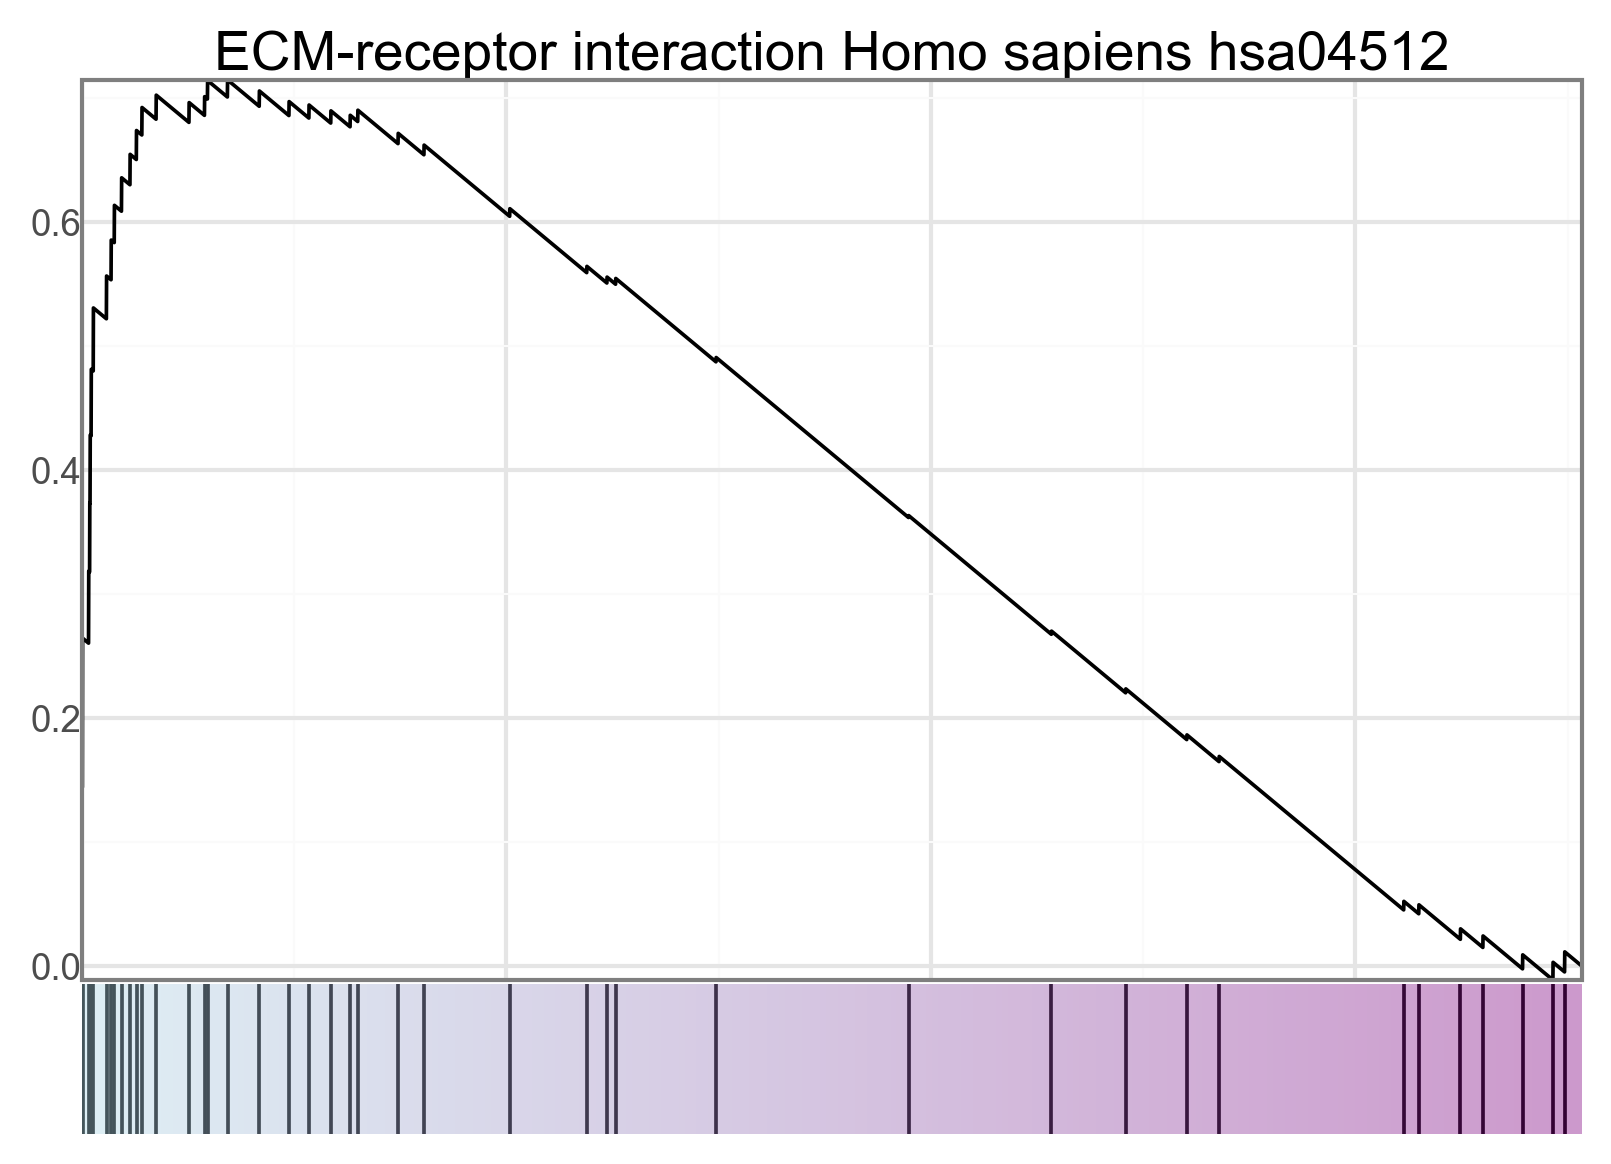

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
f1 = pw.load_ggplot(p1, figsize=(5, 3))
f2 = pw.load_ggplot(p2, figsize=(5, 0.5))
pw.vstack(f2, f1, margin=0)

In [7]:
def plot_gsea_result(pkl_file, output_file="gsea_plot.png", term_index=1):
    """
    Plot GSEA result from a .pkl file.

    Args:
        pkl_file (str): Path to the .pkl file (GSEAPy prerank result)
        output_file (str): Output file path (default: gsea_plot.png)
        term_index (int): Index of the term to plot (default: 1)
    """
    pre_res = joblib.load(pkl_file)
    terms = pre_res.res2d.Term
    term = terms[term_index]

    hits = pre_res.results[term]["hits"]
    resdata = pd.DataFrame({
        "res": pre_res.results[term]["RES"],
        "index": range(len(pre_res.results[term]["RES"]))
    })

    # Line plot
    p1 = (ggplot(resdata, aes(x='index', y='res')) +
          geom_line() +
          theme_bw() +
          theme(axis_text_x=element_blank(),
                legend_position="none",
                axis_ticks=element_blank(),
                panel_background=element_blank()) +
          xlab('') + ylab('') +
          ggtitle(term) +
          scale_x_continuous(expand=(0, 0)) +
          scale_y_continuous(expand=(0, 0)))

    # Background & vertical lines
    x_vals = np.linspace(0, len(resdata), len(resdata) * 10)
    bg_df = pd.DataFrame({'x': x_vals})
    bg_df['y'] = 0
    bg_df['fill'] = bg_df['x']

    p2 = (ggplot() +
          geom_vline(xintercept=hits, color='black') +
          xlim(0, len(resdata)-1) +
          scale_x_continuous(expand=(0, 0)) +
          geom_tile(data=bg_df, mapping=aes(x='x', y='y', fill='fill'),
                    width=0.1, height=10, alpha=0.4) +
          scale_fill_gradient(low="lightblue", high="purple") +
          theme(legend_position="none",
                axis_text=element_blank(),
                axis_ticks=element_blank(),
                axis_title=element_blank(),
                panel_background=element_blank()) +
          scale_y_continuous(expand=(0, 0)) +
          xlab('') + ylab('') +
          guides(color=False, fill=False, shape=False, size=False))

    # Combine
    f1 = pw.load_ggplot(p1, figsize=(5, 3))
    f2 = pw.load_ggplot(p2, figsize=(5, 0.5))
    pw.vstack(f2, f1, margin=0).savefig(output_file)
    print(f"✅ Plot saved to {output_file}")
plot_gsea_result(pkl_file)

✅ Plot saved to gsea_plot.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
plot_gsea_result(pkl_file)

✅ Plot saved to gsea_plot.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>